# Bragg-edge phase tomography of a corroded steel artifact

**Dual-modality (X-ray + energy-resolved neutron) simulation with NCrystal + DIANA.**

This notebook builds a *multi-phase* phantom that mimics the transverse cross
section of a **corroded carbon-steel object** — the kind of sample studied in
archaeometallurgy, infrastructure (rebar / pipeline) corrosion science, and
quench-hardened component analysis. Five labels are present:

| label | phase | crystal structure | role in the artifact |
|------:|-------|-------------------|----------------------|
| 0 | air / void | — | surroundings + a corrosion crack |
| 1 | **martensite** (α-Fe proxy) | BCC, *Im-3m* (229) | hardened metal case |
| 2 | **austenite** (γ-Fe proxy) | FCC, *Fm-3m* (225) | retained-austenite core |
| 3 | **magnetite** Fe₃O₄ | inverse spinel, *Fd-3m* (227) | inner oxide layer (low-O₂, "black rust") |
| 4 | **hematite** α-Fe₂O₃ | corundum-type, *R-3c* (167) | outer oxide layer (oxidising, "red rust") |

**Why this is a good use case.** On corroding iron the oxide scale grows in a
layered sequence — a reducing **magnetite** layer next to the metal and an
oxidising **hematite** layer outside it — and the metal underneath can carry a
hardened martensitic case over a softer/retained-austenite core. These phases
are nearly **indistinguishable by X-ray attenuation** (martensite vs austenite
differ by ~1 %; magnetite ρ≈5.15 vs hematite ρ≈5.26 g/cm³), yet each has a
**distinct Bragg-edge fingerprint** because its crystal lattice is different.
X-ray CT therefore gives the *morphology* (the crack, the layer geometry, the
voids) while an energy-resolved neutron scan gives the *crystalline phase*. We
acquire the X-ray volume **once** and scan the neutron wavelength in **30
monochromatic steps**, then classify all four solid phases from their μ(λ)
spectra. A short closing section discusses how this maps onto publishable work.

> Physics convention: E[meV] = 81.804 / λ[Å]² ;  μ[cm⁻¹] = n[atoms·Å⁻³] · σ[barn].
> Martensite is modelled as BCC α-Fe (its true body-centred-*tetragonal* lattice
> and the Cr/Ni of real stainless steels are first-order approximations).
>
> **Iron-oxide note.** NCrystal's core data library ships α-Fe and γ-Fe but *no*
> Fe₂O₃/Fe₃O₄ files, so the oxides are modelled as **isostructural analogs**: the
> corundum file (`Al2O3_sg167_Corundum.ncmat`) and spinel file
> (`MgAl2O4_sg227_MAS.ncmat`) with the cation sites substituted to Fe via the
> NCrystal `atomdb` parameter. This gives the correct space group, site topology
> and Fe+O scatterers — and so distinct, physically reasonable Bragg fingerprints
> — but the *host* lattice constants, so absolute edge wavelengths sit a few %
> off the true oxides. §11 shows the one-line `ncrystal_cif2ncmat` recipe to swap
> in exact structures for quantitative work.

In [1]:
import sys, pathlib, warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.ndimage import binary_erosion

warnings.filterwarnings("ignore")   # quieten ASTRA / NCrystal chatter

# Place ncrystal_bragg.py next to this notebook (or inside the package dir) and
# run from the repository root that contains neutron_xray_sim/.
HERE = pathlib.Path.cwd()
for p in (HERE, HERE.parent):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from neutron_xray_sim import (
    AIR,
    PhantomData,
    material_from_formula,
    project_xray,
    reconstruct,
    xray_spectrum,
)
import neutron_xray_sim.ncrystal_bragg as nb

print("DIANA neutron_xray_sim imported OK")
if nb.NCRYSTAL_AVAILABLE:
    print(f"NCrystal available: version {nb.NCRYSTAL_VERSION}")
    # The iron oxides are not in NCrystal's core data library, so they are
    # modelled as isostructural analogs (corundum/spinel with cations -> Fe).
    # Report what is configured; the loader falls back automatically.
    for key in ("magnetite", "hematite"):
        cands = nb.DEFAULT_PHASE_CFG[key]
        cands = [cands] if isinstance(cands, str) else cands
        print(f"  {key:<10} candidates: {cands[0]}  (+{len(cands)-1} fallback)")
    print("  (oxides use isostructural analogs unless dedicated .ncmat files are present)")
else:
    print("WARNING: NCrystal not found - the neutron cells will not run.")
    print("         Install with:  pip install ncrystal")


DIANA neutron_xray_sim imported OK
NCrystal available: version 4.4.4
  magnetite  candidates: Fe3O4_sg227_Magnetite.ncmat  (+2 fallback)
  hematite   candidates: Fe2O3_sg167_Hematite.ncmat  (+1 fallback)
  (oxides use isostructural analogs unless dedicated .ncmat files are present)


## 1 · Configuration

A single transverse slice (`NZ = 1`) of a cylindrical artifact, 40 µm voxels.
The neutron band is widened slightly to **1.8–5.8 Å** so it brackets the longer-
*d* Bragg edges of the iron oxides (e.g. magnetite (311)≈5.06 Å, hematite
(104)≈5.40 Å) as well as the steel edges (α-Fe (110)≈4.05 Å, γ-Fe (111)≈4.15 Å).

In [2]:
# ── Geometry ─────────────────────────────────────────────────────────────────
NX = NY = 256
NZ = 1
VOXEL_CM = 0.004                  # 40 µm  ->  FOV = 1.024 cm

# Concentric radii (cm), metal core outward.
R_AUST = 0.12                     # retained-austenite core
R_CORE = 0.26                     # martensitic metal case (outer edge of metal)
R_MAG  = 0.36                     # magnetite inner-oxide layer outer edge
R_OUT  = 0.46                     # hematite outer-oxide layer / artifact surface

# ── Labels ───────────────────────────────────────────────────────────────────
LABEL_AIR, LABEL_MART, LABEL_AUST, LABEL_MAG, LABEL_HEM = 0, 1, 2, 3, 4
PHASE_NAMES  = ["air", "martensite", "austenite", "magnetite", "hematite"]
PHASE_COLORS = ["#1b1b1b", "#C44E52", "#4C72B0", "#55A868", "#DD8452"]

# ── Neutron wavelength scan (30 monochromatic steps) ─────────────────────────
N_STEPS  = 30
WL_MIN_A, WL_MAX_A = 1.8, 5.8
WAVELENGTHS_A = np.linspace(WL_MIN_A, WL_MAX_A, N_STEPS)
ENERGIES_MEV  = nb.wavelength_A_to_energy_meV(WAVELENGTHS_A)

# ── Acquisition / reconstruction ─────────────────────────────────────────────
N_ANGLES   = 180
ANGLES_DEG = np.linspace(0.0, 180.0, N_ANGLES, endpoint=False)
ALGORITHM  = "FBP"
USE_ASTRA  = True                 # auto-falls back to skimage FBP if absent
TEMPERATURE_K = 293.15
KVP, AL_FILTER_MM = 160.0, 2.0    # hard X-ray beam (steel + oxides are dense)

OUTPUT_DIR = pathlib.Path("outputs_corrosion_bragg")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Neutron scan: {N_STEPS} steps, lambda in [{WL_MIN_A}, {WL_MAX_A}] A "
      f"(E in [{ENERGIES_MEV.min():.2f}, {ENERGIES_MEV.max():.2f}] meV)")
print(f"Artifact: 4 solid phases, outer diameter {2*R_OUT*10:.1f} mm, "
      f"voxel {VOXEL_CM*1e4:.0f} um")


Neutron scan: 30 steps, lambda in [1.8, 5.8] A (E in [2.43, 25.25] meV)
Artifact: 4 solid phases, outer diameter 9.2 mm, voxel 40 um


## 2 · X-ray material properties

The X-ray attenuation is built from chemical formulas and realistic densities
(DIANA's formula parser supports Fe, Ni and O). The contrast table makes the
central point: **X-rays barely separate the two metals from each other, or the
two oxides from each other** — they separate *metal from oxide from void* by
density, but not the crystallographic phases. That separation is what the
neutron Bragg-edge scan provides.

In [3]:
mat_martensite = material_from_formula(
    name="Martensite (alpha-Fe proxy)", symbol="Mart",
    formula="Fe", density_gcc=7.75, color=PHASE_COLORS[LABEL_MART])
mat_austenite = material_from_formula(
    name="Austenite (gamma-Fe/Fe-Ni proxy)", symbol="Aust",
    formula="Fe0.92Ni0.08", density_gcc=7.95, color=PHASE_COLORS[LABEL_AUST])
mat_magnetite = material_from_formula(
    name="Magnetite Fe3O4", symbol="Mag",
    formula="Fe3O4", density_gcc=5.15, color=PHASE_COLORS[LABEL_MAG])
mat_hematite = material_from_formula(
    name="Hematite Fe2O3", symbol="Hem",
    formula="Fe2O3", density_gcc=5.26, color=PHASE_COLORS[LABEL_HEM])

MATERIALS = [AIR, mat_martensite, mat_austenite, mat_magnetite, mat_hematite]

E_bins, w_bins = xray_spectrum(kVp=KVP, filter_mm_Al=AL_FILTER_MM, n_bins=12)
print(f"{'Material':<30}{'rho (g/cm3)':>12}{'mu_x_eff (cm^-1)':>18}")
for m in MATERIALS[1:]:
    mu_x_eff = float(np.sum(w_bins * m.mu_x_array(E_bins)))
    print(f"{m.name:<30}{m.density_gcc:>12.2f}{mu_x_eff:>18.4f}")


Material                       rho (g/cm3)  mu_x_eff (cm^-1)
Martensite (alpha-Fe proxy)           7.75           11.4776
Austenite (gamma-Fe/Fe-Ni proxy)        7.95           12.0205
Magnetite Fe3O4                       5.15            5.7882
Hematite Fe2O3                        5.26            5.7476


## 3 · Multi-phase corroded-artifact phantom

Construction is purely geometric (polar coordinates centred on the axis):

* concentric layers — austenite core → martensite case → magnetite layer →
  hematite layer;
* three small **magnetite nodules** embedded in the hematite layer (isolated
  inner-oxide pockets, a real corrosion microstructure feature, and a test of
  small-inclusion classification);
* one **corrosion crack** — an air wedge that has eaten through both oxide
  layers and into the metal case. X-ray CT will resolve its shape; the neutron
  scan will reveal which phase lines its walls.

  label 0 (air        ):   25538 voxels
  label 1 (martensite ):   10126 voxels
  label 2 (austenite  ):    2828 voxels
  label 3 (magnetite  ):   12116 voxels
  label 4 (hematite   ):   14928 voxels


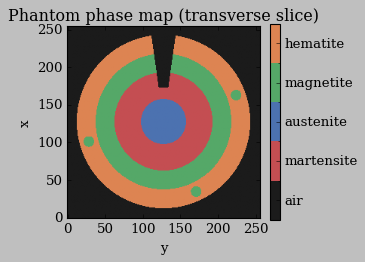

In [4]:
ax = (np.arange(NX) - (NX - 1) / 2) * VOXEL_CM
ay = (np.arange(NY) - (NY - 1) / 2) * VOXEL_CM
X, Y = np.meshgrid(ax, ay, indexing="ij")          # axis1 = x, axis2 = y
R     = np.hypot(X, Y)
THETA = np.arctan2(Y, X)                            # radians, -pi..pi

label2d = np.full((NX, NY), LABEL_AIR, dtype=np.uint8)
label2d[R <= R_OUT]  = LABEL_HEM                    # outer oxide
label2d[R <= R_MAG]  = LABEL_MAG                    # inner oxide
label2d[R <= R_CORE] = LABEL_MART                   # metal case
label2d[R <= R_AUST] = LABEL_AUST                   # retained-austenite core

# Magnetite nodules embedded in the hematite shell (centre radius ~0.41 cm).
for ang_deg in (70.0, 155.0, 255.0):
    a = np.deg2rad(ang_deg)
    cx, cy = 0.41 * np.cos(a), 0.41 * np.sin(a)
    label2d[np.hypot(X - cx, Y - cy) <= 0.028] = LABEL_MAG

# Corrosion crack: an air wedge near +x, through both oxides into the case.
crack = (R <= R_OUT) & (np.abs(THETA) <= np.deg2rad(8.0)) & (R >= 0.18)
label2d[crack] = LABEL_AIR

label_vol = label2d[np.newaxis, :, :]              # (NZ, NX, NY)

phantom = PhantomData(
    Nz=NZ, Nx=NX, Ny=NY, voxel_cm=VOXEL_CM,
    label_vol=label_vol, materials=MATERIALS,
    name="corroded_steel_artifact")

for lbl, nm in enumerate(PHASE_NAMES):
    print(f"  label {lbl} ({nm:<11}): {int((label_vol == lbl).sum()):>7d} voxels")

cmap = ListedColormap(PHASE_COLORS)
norm = BoundaryNorm(np.arange(-0.5, 5.5, 1.0), cmap.N)
fig, axp = plt.subplots(figsize=(4.6, 4.6))
im = axp.imshow(label_vol[0], cmap=cmap, norm=norm, origin="lower")
axp.set_title("Phantom phase map (transverse slice)")
axp.set_xlabel("y"); axp.set_ylabel("x")
cb = plt.colorbar(im, ax=axp, fraction=0.046, ticks=range(5))
cb.ax.set_yticklabels(PHASE_NAMES)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "phantom_labels.png", dpi=150, bbox_inches="tight")
plt.show()


## 4 · NCrystal cross sections for the four phases

Each phase is loaded from its NCrystal data file; the macroscopic attenuation
is `μ = n · σ_total` with `n` the atomic number density reported by NCrystal.
The four μ(λ) curves below have clearly different edge positions — that is the
information the wavelength scan exploits.

martensite   rho= 7.87 g/cm3  n=0.0848 /A^3   edges(A)=[4.054 2.866 2.34 ]
             cfg: Fe_sg229_Iron-alpha.ncmat;temp=293.15
austenite    rho= 7.58 g/cm3  n=0.0817 /A^3   edges(A)=[4.145 3.59  2.539]
             cfg: Fe_sg225_Iron-gamma.ncmat;temp=293.15
magnetite    rho= 5.83 g/cm3  n=0.1061 /A^3   edges(A)=[5.936 5.064 4.198 2.968]
             cfg: MgAl2O4_sg227_MAS.ncmat;atomdb=Mg is Fe@Al is Fe;temp=293.15
hematite     rho= 6.25 g/cm3  n=0.1179 /A^3   edges(A)=[5.401 5.038 4.412 3.686]
             cfg: Al2O3_sg167_Corundum.ncmat;atomdb=Al is Fe;temp=293.15


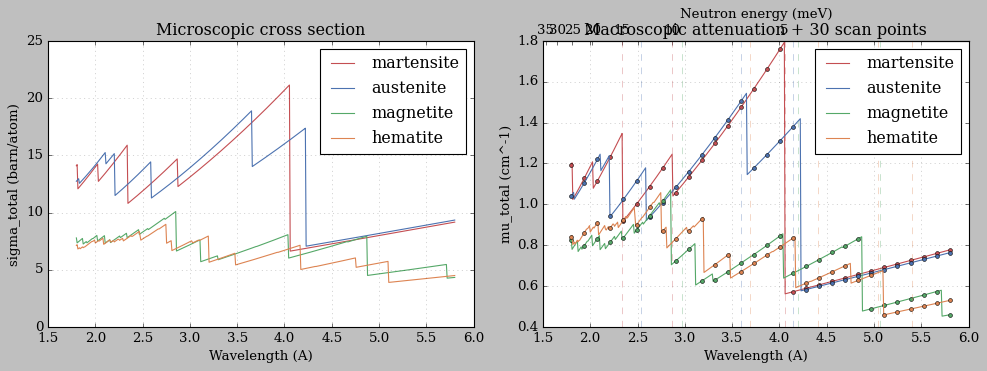

In [5]:
phase_mart = nb.load_phase("martensite", temperature_K=TEMPERATURE_K)
phase_aust = nb.load_phase("austenite",  temperature_K=TEMPERATURE_K)
phase_mag  = nb.load_phase("magnetite",  temperature_K=TEMPERATURE_K)
phase_hem  = nb.load_phase("hematite",   temperature_K=TEMPERATURE_K)
PHASES_BY_LABEL = [None, phase_mart, phase_aust, phase_mag, phase_hem]

# Ground-truth mu(lambda) LUT, shape (n_labels, n_steps), cm^-1.
mu_lut = nb.mu_n_bragg_lut(PHASES_BY_LABEL, WAVELENGTHS_A, temperature_K=TEMPERATURE_K)

_FALLBACK_EDGES = {
    "martensite": [4.054, 2.866, 2.340],
    "austenite":  [4.145, 3.590, 2.539],
    "magnetite":  [5.936, 5.064, 4.198, 2.968],
    "hematite":   [5.401, 5.038, 4.412, 3.686],
}
def edges_of(phase, key):
    e = phase.bragg_edges_A(5)
    return e if getattr(e, "size", 0) else np.asarray(_FALLBACK_EDGES[key])

EDGES = {
    LABEL_MART: edges_of(phase_mart, "martensite"),
    LABEL_AUST: edges_of(phase_aust, "austenite"),
    LABEL_MAG:  edges_of(phase_mag,  "magnetite"),
    LABEL_HEM:  edges_of(phase_hem,  "hematite"),
}
for lbl in (LABEL_MART, LABEL_AUST, LABEL_MAG, LABEL_HEM):
    ph = PHASES_BY_LABEL[lbl]
    print(f"{PHASE_NAMES[lbl]:<12} rho={ph.density_gcc:5.2f} g/cm3  "
          f"n={ph.number_density_per_A3:.4f} /A^3   "
          f"edges(A)={np.round(EDGES[lbl], 3)}")
    print(f"             cfg: {ph.cfg_used}")

wl_dense = np.linspace(WL_MIN_A, WL_MAX_A, 500)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12.5, 4.8))
for lbl in (LABEL_MART, LABEL_AUST, LABEL_MAG, LABEL_HEM):
    ph = PHASES_BY_LABEL[lbl]
    axL.plot(wl_dense, ph.sigma_total_barn(wl_dense),
             color=PHASE_COLORS[lbl], label=PHASE_NAMES[lbl])
    axR.plot(wl_dense, ph.mu_total_cm(wl_dense),
             color=PHASE_COLORS[lbl], label=PHASE_NAMES[lbl])
    axR.plot(WAVELENGTHS_A, mu_lut[lbl], "o", ms=3.5, color=PHASE_COLORS[lbl])
    for e in EDGES[lbl]:
        if WL_MIN_A <= e <= WL_MAX_A:
            axR.axvline(e, color=PHASE_COLORS[lbl], ls="--", lw=0.7, alpha=0.4)
axL.set_xlabel("Wavelength (A)"); axL.set_ylabel("sigma_total (barn/atom)")
axL.set_title("Microscopic cross section"); axL.legend(); axL.grid(alpha=0.3)
axR.set_xlabel("Wavelength (A)"); axR.set_ylabel("mu_total (cm^-1)")
axR.set_title("Macroscopic attenuation + 30 scan points")
axR.legend(); axR.grid(alpha=0.3)
secax = axR.secondary_xaxis("top", functions=(
    lambda l: nb.wavelength_A_to_energy_meV(np.clip(l, 1e-6, None)),
    lambda e: nb.energy_meV_to_wavelength_A(np.clip(e, 1e-6, None))))
secax.set_xlabel("Neutron energy (meV)")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "cross_sections.png", dpi=150, bbox_inches="tight")
plt.show()


## 5 · X-ray acquisition (once)

A single polychromatic X-ray CT acquisition + FBP reconstruction gives the
morphology and a sample mask. Note in the printout that X-ray cannot tell
martensite from austenite, nor magnetite from hematite.

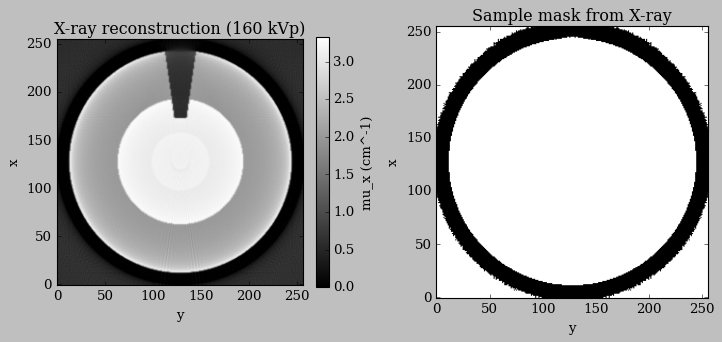

Phase          mean mu_x (cm^-1)
martensite                3.1446
austenite                 3.1427
magnetite                 2.0592
hematite                  2.3812

-> metals nearly equal; oxides nearly equal: X-ray alone cannot separate the crystallographic phases.


In [6]:
xray_sino = project_xray(
    phantom, ANGLES_DEG, kVp=KVP, filter_mm_Al=AL_FILTER_MM,
    n_spectrum_bins=12, use_astra=USE_ASTRA, I0=1e5)
vol_x = reconstruct(xray_sino, algorithm=ALGORITHM, use_astra=USE_ASTRA)
xray_slice = vol_x[0]                          # (NX, NY) in cm^-1

sample_mask = xray_slice > 0.12 * xray_slice.max()   # geometry only

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.2, 4.5))
im1 = a1.imshow(xray_slice, cmap="gray", origin="lower")
a1.set_title(f"X-ray reconstruction ({KVP:.0f} kVp)")
plt.colorbar(im1, ax=a1, fraction=0.046, label="mu_x (cm^-1)")
a2.imshow(sample_mask, cmap="gray", origin="lower")
a2.set_title("Sample mask from X-ray")
for a in (a1, a2):
    a.set_xlabel("y"); a.set_ylabel("x")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "xray.png", dpi=150, bbox_inches="tight")
plt.show()

def erode(mask, k=3):
    return binary_erosion(mask, iterations=k)

print(f"{'Phase':<12}{'mean mu_x (cm^-1)':>20}")
for lbl in (LABEL_MART, LABEL_AUST, LABEL_MAG, LABEL_HEM):
    roi = erode(label_vol[0] == lbl)
    if roi.any():
        print(f"{PHASE_NAMES[lbl]:<12}{xray_slice[roi].mean():>20.4f}")
print("\n-> metals nearly equal; oxides nearly equal: X-ray alone cannot "
      "separate the crystallographic phases.")


## 6 · Neutron Bragg-edge scan (30 wavelengths)

`run_bragg_edge_scan` re-patches the phantom's neutron attenuation for each
wavelength (from the NCrystal LUT) and runs an independent projection +
reconstruction, returning a `(n_steps, NZ, NX, NY)` stack in cm⁻¹.

  [ 1/30] λ = 1.800 Å  (E = 25.248 meV)
  [ 2/30] λ = 1.938 Å  (E = 21.782 meV)
  [ 3/30] λ = 2.076 Å  (E = 18.984 meV)
  [ 4/30] λ = 2.214 Å  (E = 16.692 meV)
  [ 5/30] λ = 2.352 Å  (E = 14.791 meV)
  [ 6/30] λ = 2.490 Å  (E = 13.198 meV)
  [ 7/30] λ = 2.628 Å  (E = 11.848 meV)
  [ 8/30] λ = 2.766 Å  (E = 10.696 meV)
  [ 9/30] λ = 2.903 Å  (E =  9.704 meV)
  [10/30] λ = 3.041 Å  (E =  8.844 meV)
  [11/30] λ = 3.179 Å  (E =  8.093 meV)
  [12/30] λ = 3.317 Å  (E =  7.434 meV)
  [13/30] λ = 3.455 Å  (E =  6.852 meV)
  [14/30] λ = 3.593 Å  (E =  6.336 meV)
  [15/30] λ = 3.731 Å  (E =  5.876 meV)
  [16/30] λ = 3.869 Å  (E =  5.465 meV)
  [17/30] λ = 4.007 Å  (E =  5.095 meV)
  [18/30] λ = 4.145 Å  (E =  4.762 meV)
  [19/30] λ = 4.283 Å  (E =  4.460 meV)
  [20/30] λ = 4.421 Å  (E =  4.186 meV)
  [21/30] λ = 4.559 Å  (E =  3.936 meV)
  [22/30] λ = 4.697 Å  (E =  3.709 meV)
  [23/30] λ = 4.834 Å  (E =  3.500 meV)
  [24/30] λ = 4.972 Å  (E =  3.309 meV)
  [25/30] λ = 5.110 Å  (E =  3.132 meV)


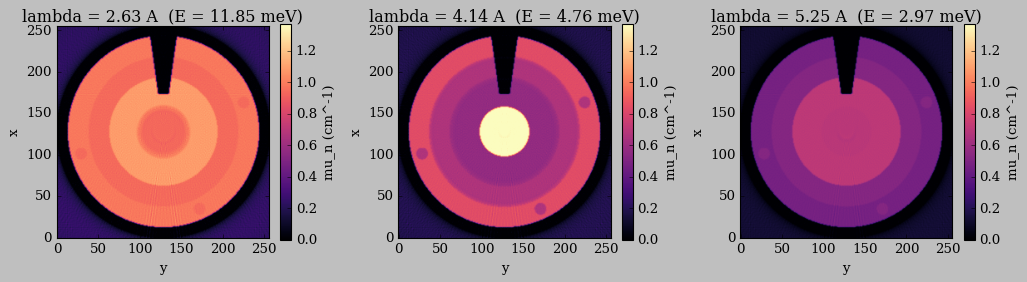

In [7]:
scan = nb.run_bragg_edge_scan(
    phantom, phases_by_label=PHASES_BY_LABEL, wavelengths_A=WAVELENGTHS_A,
    angles_deg=ANGLES_DEG, algorithm=ALGORITHM, I0=1e6,
    use_astra=USE_ASTRA, temperature_K=TEMPERATURE_K, verbose=True)
vol_n_stack = scan["vol_n"][:, 0, :, :]        # (n_steps, NX, NY)
print("\nReconstructed neutron stack:", vol_n_stack.shape)

idxs = [int(np.argmin(np.abs(WAVELENGTHS_A - w))) for w in (2.6, 4.1, 5.3)]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
vmax = np.percentile(vol_n_stack[idxs], 99)
for axn, i in zip(axes, idxs):
    im = axn.imshow(vol_n_stack[i], cmap="magma", origin="lower", vmin=0, vmax=vmax)
    axn.set_title(f"lambda = {WAVELENGTHS_A[i]:.2f} A  (E = {ENERGIES_MEV[i]:.2f} meV)")
    axn.set_xlabel("y"); axn.set_ylabel("x")
    plt.colorbar(im, ax=axn, fraction=0.046, label="mu_n (cm^-1)")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "neutron_slices.png", dpi=150, bbox_inches="tight")
plt.show()


## 7 · Reconstructed Bragg-edge spectra vs NCrystal ground truth

For each phase we average the reconstructed μ over an eroded interior ROI and
compare with the NCrystal reference curve.

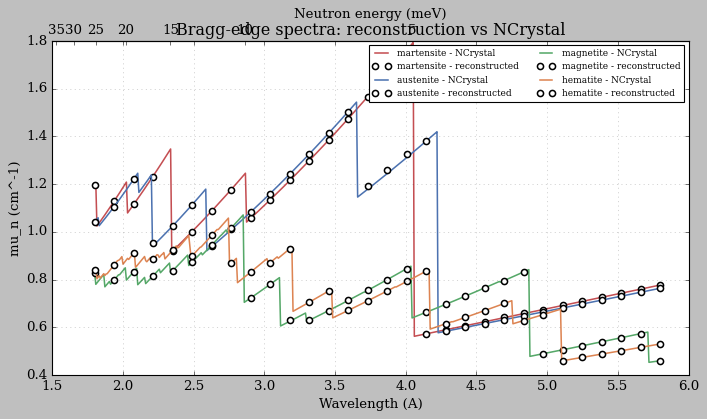

  martensite   ROI-vs-NCrystal RMSE = 0.0010 cm^-1
  austenite    ROI-vs-NCrystal RMSE = 0.0048 cm^-1
  magnetite    ROI-vs-NCrystal RMSE = 0.0009 cm^-1
  hematite     ROI-vs-NCrystal RMSE = 0.0002 cm^-1


In [8]:
ROIS = {lbl: erode(label_vol[0] == lbl)
        for lbl in (LABEL_MART, LABEL_AUST, LABEL_MAG, LABEL_HEM)}
meas = {lbl: np.array([vol_n_stack[i][ROIS[lbl]].mean() for i in range(N_STEPS)])
        for lbl in ROIS}

fig, ax = plt.subplots(figsize=(9, 5.4))
for lbl in (LABEL_MART, LABEL_AUST, LABEL_MAG, LABEL_HEM):
    ph = PHASES_BY_LABEL[lbl]
    ax.plot(wl_dense, ph.mu_total_cm(wl_dense), color=PHASE_COLORS[lbl], lw=1.4,
            label=f"{PHASE_NAMES[lbl]} - NCrystal")
    ax.plot(WAVELENGTHS_A, meas[lbl], "o", color=PHASE_COLORS[lbl], ms=5.5,
            mfc="white", mew=1.4, label=f"{PHASE_NAMES[lbl]} - reconstructed")
ax.set_xlabel("Wavelength (A)"); ax.set_ylabel("mu_n (cm^-1)")
ax.set_title("Bragg-edge spectra: reconstruction vs NCrystal")
secax = ax.secondary_xaxis("top", functions=(
    lambda l: nb.wavelength_A_to_energy_meV(np.clip(l, 1e-6, None)),
    lambda e: nb.energy_meV_to_wavelength_A(np.clip(e, 1e-6, None))))
secax.set_xlabel("Neutron energy (meV)")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "bragg_spectra.png", dpi=150, bbox_inches="tight")
plt.show()

for lbl in (LABEL_MART, LABEL_AUST, LABEL_MAG, LABEL_HEM):
    rmse = np.sqrt(np.mean((meas[lbl] - mu_lut[lbl])**2))
    print(f"  {PHASE_NAMES[lbl]:<12} ROI-vs-NCrystal RMSE = {rmse:.4f} cm^-1")


## 8 · Four-phase classification + dual-modality separation

Each in-sample pixel carries a 30-point μ(λ) spectrum. `classify_phases`
assigns it to the nearest NCrystal reference by cosine similarity (scale-
invariant, so it keys on edge *shape*). We then visualise why the two modalities
are complementary: in a joint (μ_x, μ_n) plane the metals and oxides separate by
X-ray density, while martensite/austenite and magnetite/hematite — degenerate in
X-ray — separate along the neutron axis.

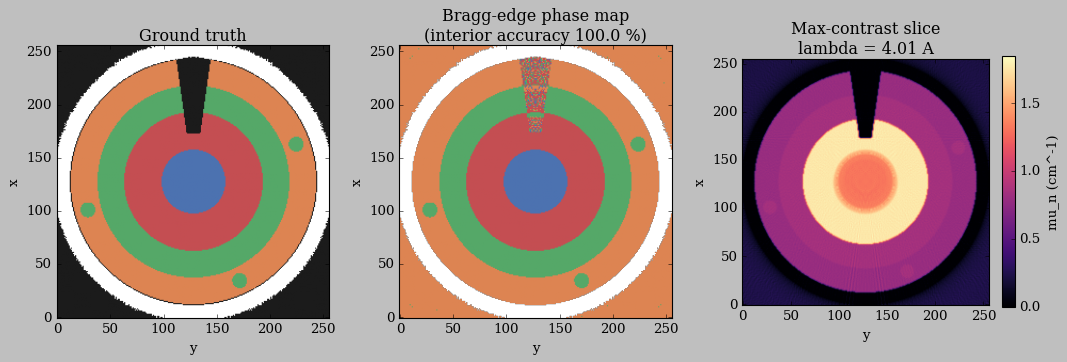

Four-phase classification accuracy on interior pixels: 100.00 %


In [9]:
reference = mu_lut[[LABEL_MART, LABEL_AUST, LABEL_MAG, LABEL_HEM], :]  # (4, n_steps)
phase_map = nb.classify_phases(vol_n_stack, reference, mask=sample_mask)

gt_map = label_vol[0].astype(np.int16)
score_region = np.zeros((NX, NY), bool)
for lbl in ROIS:
    score_region |= ROIS[lbl]
acc = float((phase_map[score_region] == gt_map[score_region]).mean()) * 100.0

# Most discriminating single wavelength (max spread across the 4 references).
i_contrast = int(np.argmax(reference.max(axis=0) - reference.min(axis=0)))

cmap = ListedColormap(PHASE_COLORS)
norm = BoundaryNorm(np.arange(-0.5, 5.5, 1.0), cmap.N)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6))
axes[0].imshow(np.where(sample_mask, gt_map, np.nan), cmap=cmap, norm=norm, origin="lower")
axes[0].set_title("Ground truth")
axes[1].imshow(np.where(sample_mask, phase_map, np.nan), cmap=cmap, norm=norm, origin="lower")
axes[1].set_title(f"Bragg-edge phase map\n(interior accuracy {acc:.1f} %)")
im = axes[2].imshow(vol_n_stack[i_contrast], cmap="magma", origin="lower")
axes[2].set_title(f"Max-contrast slice\nlambda = {WAVELENGTHS_A[i_contrast]:.2f} A")
plt.colorbar(im, ax=axes[2], fraction=0.046, label="mu_n (cm^-1)")
for a in axes:
    a.set_xlabel("y"); a.set_ylabel("x")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "phase_map.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Four-phase classification accuracy on interior pixels: {acc:.2f} %")


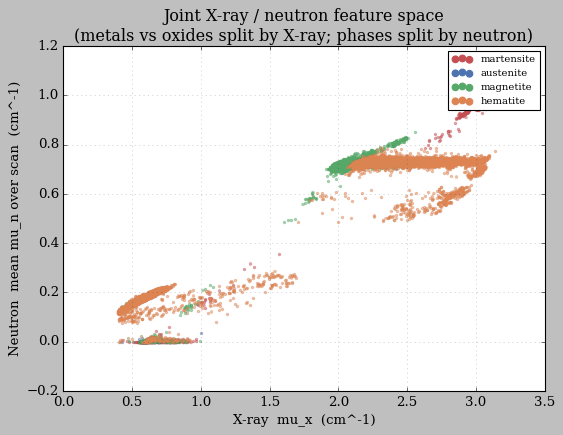

In [10]:
# Dual-modality scatter: X-ray mu vs mean neutron mu, coloured by classified phase.
mu_n_mean = vol_n_stack.mean(axis=0)
fig, axj = plt.subplots(figsize=(7.2, 5.6))
for lbl in (LABEL_MART, LABEL_AUST, LABEL_MAG, LABEL_HEM):
    sel = sample_mask & (phase_map == lbl)
    if sel.any():
        axj.scatter(xray_slice[sel], mu_n_mean[sel], s=4, alpha=0.25,
                    color=PHASE_COLORS[lbl], label=PHASE_NAMES[lbl])
axj.set_xlabel("X-ray  mu_x  (cm^-1)")
axj.set_ylabel("Neutron  mean mu_n over scan  (cm^-1)")
axj.set_title("Joint X-ray / neutron feature space\n"
              "(metals vs oxides split by X-ray; phases split by neutron)")
leg = axj.legend(markerscale=3, fontsize=9)
for h in leg.legend_handles:
    h.set_alpha(1.0)
axj.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "joint_feature_space.png", dpi=150, bbox_inches="tight")
plt.show()


## 9 · Save results

In [11]:
np.savez_compressed(
    OUTPUT_DIR / "corrosion_bragg_results.npz",
    wavelengths_A=WAVELENGTHS_A, energies_meV=ENERGIES_MEV,
    mu_lut=mu_lut, vol_x=vol_x, vol_n_stack=vol_n_stack,
    phase_map=phase_map, label_vol=label_vol,
    meas_martensite=meas[LABEL_MART], meas_austenite=meas[LABEL_AUST],
    meas_magnetite=meas[LABEL_MAG], meas_hematite=meas[LABEL_HEM])
print("Saved arrays and figures to:", OUTPUT_DIR.resolve())
for p in sorted(OUTPUT_DIR.iterdir()):
    print("  ", p.name)


Saved arrays and figures to: /tmp2/Oriol/Bimodal_simulation/Bimodal_simulation-main/outputs_corrosion_bragg
   bragg_spectra.png
   corrosion_bragg_results.npz
   cross_sections.png
   joint_feature_space.png
   neutron_slices.png
   phantom_labels.png
   phase_map.png
   xray.png


---
## 10 · Toward a high-ranking publication

Energy-resolved (Bragg-edge) neutron imaging combined with X-ray CT is an active
method with a real publication record, and this simulation maps directly onto
several open problems. Concrete, defensible angles:

**A. Correlative dual-modality phase + corrosion tomography of heritage / buried iron.**
Non-destructive mapping of the magnetite/hematite (and, if added, akaganéite
β-FeOOH, goethite α-FeOOH, maghemite γ-Fe₂O₃) corrosion layers in archaeological
or infrastructure iron is of high interest, because the *ratio and spatial
arrangement* of these phases diagnoses the corrosion mechanism and the long-term
stability of the object. X-ray gives morphology/cracking; Bragg-edge neutrons
give the crystalline phase. Suitable venues: *Journal of Cultural Heritage*,
*Materials Characterization*, *Corrosion Science*, *npj Materials Degradation*.

**B. Retained-austenite / martensite quantification in hardened or additively
manufactured steel.** Bragg-edge tomography already maps the γ→α′ transformation
in TRIP steels and quench/induction-hardened components; extending to a
volumetric phase-*fraction* map with an X-ray geometric prior is publishable in
*Acta Materialia*, *Scripta Materialia*, *Additive Manufacturing*, or
*Journal of Applied Crystallography*.

**C. A methods/instrumentation paper on acquisition-efficient Bragg-edge CT.**
The recognised bottleneck is that scanning many wavelengths over many projection
angles is slow, so full tomography is rare. A simulation that (i) reuses a single
X-ray CT as a geometric/segmentation prior, and (ii) **optimises which ~30
wavelengths to measure** to maximise multi-phase separability per unit beamtime,
is a genuine contribution. Frame it as experiment design / optimal sampling and
target *Review of Scientific Instruments*, *Journal of Imaging*, *Nuclear Instr.
and Methods A*, or *Optics Express*. The forward model here is exactly the
testbed such a study needs.

**D. Reconstruction-algorithm development.** Joint or spectral reconstruction
(treating the 30 wavelengths as correlated channels — e.g. spectral TV, low-rank,
or a learned phase-fraction prior) instead of 30 independent FBPs would reduce
dose/beamtime and improve phase maps. Comparing algorithms on this controlled,
ground-truth phantom suits *IEEE Trans. Computational Imaging*, *Inverse
Problems*, or *Journal of Imaging*.

**To make any of these submission-grade**, the model should be tightened beyond
the proxies used here: use body-centred-tetragonal martensite and true alloy
compositions; add realistic counting (Poisson) noise, beam spectrum and detector
response; model the coherent-edge wavelength dependence in the projector itself
rather than only via the per-wavelength μ patch; validate against a real IMAT /
RADEN / ODIN dataset; and quantify phase *fractions* with uncertainties, not just
a hard classification. Facilities to cite/target: **IMAT** (ISIS, UK), **RADEN**
(J-PARC, Japan), and **ODIN** (ESS, Sweden).

> These are research directions, not guarantees — novelty and rigour relative to
> existing literature determine where work lands. A focused, well-validated study
> on one of A–D is more publishable than a broad demonstration of all four.

---
## 11 · Upgrading the iron-oxide structures to exact data

The oxides above are isostructural analogs (corundum/spinel hosts with cations
substituted to Fe), so their edge wavelengths are a few % off. For quantitative
results, replace them with exact NCMAT files. The fastest route uses NCrystal's
own converter on a CIF (from e.g. the Crystallography Open Database or Materials
Project — hematite α-Fe₂O₃ R-3c, magnetite Fe₃O₄ Fd-3m):

```bash
ncrystal_cif2ncmat  Fe2O3_hematite.cif   -o  Fe2O3_Hematite.ncmat
ncrystal_cif2ncmat  Fe3O4_magnetite.cif  -o  Fe3O4_Magnetite.ncmat
```

Then point the loader at the real files (no other change needed):

```python
nb.DEFAULT_PHASE_CFG["hematite"]  = "Fe2O3_Hematite.ncmat"
nb.DEFAULT_PHASE_CFG["magnetite"] = "Fe3O4_Magnetite.ncmat"
```

You can confirm what your NCrystal build already provides with
`nb.available_ncmat("Fe")` or, at the command line, `nctool --browse | grep -i Fe`.
`load_phase` tries a dedicated `Fe2O3…`/`Fe3O4…` file first and only falls back
to the analog if none is found, so simply having the exact files on the NCrystal
search path is enough.